# T18 — REVEAL tomography slices with reconstructed plate boundaries

**Are the deep slabs imaged in seismic tomography the ghosts of past subduction zones?**

## What this notebook produces

A single worked example map at 1500 km depth through the REVEAL (https://reveal.sciencesconf.org/) global full-waveform-inversion model (Thrastarson et al., 2024), overlain with reconstructed paleo-trenches from the Zahirovic et al. (2022) plate model at the time corresponding to that depth under a two-layer slab-sinking-speed model (faster in the upper mantle, slower in the lower mantle — see Section 2 below). The example map is followed by a T07-style Panel slider that scrubs through **ten bundled depth slices** (500, 650, 850, 1000, 1250, 1500, 1750, 2000, 2250, 2500 km) — each renders a fresh reconstruction at its sinking-rate-derived age and the corresponding REVEAL slice, so dragging the slider walks you back through the slab-graveyard history of the mantle.

Where the reconstructed teeth are located directly on blue (fast) tomographic patches, the slab-graveyard signal is direct: today's deep, cold anomaly is the relic of past subduction at that geographic position. Where teeth are located over plain (mean) tomography, the match fails — possibly because the assumed sinking rate is wrong for that slab, possibly because the reconstruction model is wrong for that age, possibly both.

**Audience**: postgraduate.  
**Difficulty**: ★★★.  
**Runtime**: a few seconds for the worked-example map; ~1–2 min for the 10-frame Panel pre-render the first time.

## Learning objectives

- Load REVEAL (https://reveal.sciencesconf.org/) global tomography depth slices as `xarray.DataArray` and render them with pyGMT `grdimage`.
- Map a chosen depth slice to a reconstruction age using the Butterworth 2014 two-layer slab-sinking model (5 cm/yr upper, 1.3 cm/yr lower).
- Overlay reconstructed subduction zones on the slice and explain the dVs–trench alignment as imaged sinking slabs.


## Prerequisites and runtime

- **Plate model**: Zahirovic 2022.
- **Tomography**: REVEAL (https://reveal.sciencesconf.org/) global slices, bundled at `data/reveal_tomography/`.
- **Depth**: 1500 km → ~80 Ma reconstruction (per the 2-layer sinking model).
- **Python**: `gplately`, `pygmt`, `pygplates`, `xarray`, `numpy`.
- **Runtime**: ~1 minute.


In [1]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports + locate the bundled REVEAL depth slices
from pathlib import Path
import xarray as xr, numpy as np, gplately, pygmt
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML

# Suite-wide tutorial style: bigger panel titles, 1 cm gap between figures.
pygmt.config(FONT_TITLE="18p", FONT_LABEL="18p",
             FONT_ANNOT_PRIMARY="14p")

# Three pre-extracted REVEAL depth slices ship with this tutorial under
# data/reveal_tomography/. Each is a single-variable netcdf of vsv
# perturbation (dVs in %) relative to the depth-slice mean — the standard
# tomography display variable. Source: REVEAL global full-waveform
# inversion model (Thrastarson et al. 2024,
# https://doi.org/10.1785/0120230273); we sliced their 99-depth model file
# once and saved three representative depths to keep the bundle small
# (~800 kB each, 99% smaller than the original 394 MB file).
DATA_CANDIDATES = [
    Path("./data/reveal_tomography"),
    Path("../data/reveal_tomography"),
]
REVEAL_DIR = next((c for c in DATA_CANDIDATES if c.exists()), None)
if REVEAL_DIR is None:
    raise FileNotFoundError(
        "data/reveal_tomography/ not found — the depth slices ship with "
        "this tutorial suite. Run Jupyter from the project root or Notebooks/."
    )
AVAILABLE_DEPTHS = sorted(int(p.stem.split("_")[-1].rstrip("km"))
                          for p in REVEAL_DIR.glob("REVEAL_dvs_*km.nc"))
print(f"Bundled REVEAL slices: {AVAILABLE_DEPTHS} km")
# Library versions (printed for reproducibility)
try:
    import gplately, pygmt, pygplates
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")


Bundled REVEAL slices: [500, 650, 850, 1000, 1250, 1500, 1750, 2000, 2250, 2500] km
gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration

User-tunable choices for this notebook. Edit the values below to change the model, snapshot time, region, or anchor plate without hunting through downstream code.


In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME           = "Zahirovic2022"
DEPTH_KM             = 1500.0        # depth slice rendered (km)
V_UPPER_CMYR         = 5.0           # Butterworth 2014: upper-mantle slab sinking
V_LOWER_CMYR         = 1.3           # Butterworth 2014: lower-mantle slab sinking
RECONSTRUCTION_TIME  = 80.0          # Ma — corresponds to 1500 km via two-layer model
ANCHOR_PLATE_ID      = 0
# ============================================================================


## 2. From tomographic depth to reconstruction age — a depth-dependent slab-sinking model

Overlaying *reconstructed* paleo-trenches on a *present-day* tomographic slice requires a depth-to-age mapping. Slab sinking speeds are commonly parameterised as **depth dependent**, with faster descent through the upper mantle than through the lower mantle.

For the **upper mantle**, published estimates span ~1.5–6 cm/yr (Domeier et al. 2016), with values around 3–5 cm/yr most often adopted in geodynamic models. For the **lower mantle**, sinking is markedly slower: empirical compilations give 1.2 ± 0.3 cm/yr (van der Meer et al. 2010) and 1.3 ± 0.3 cm/yr (Butterworth et al. 2014), and geodynamic models converge on similar values.

We adopt **Butterworth et al. (2014)** as the default in this notebook: **5 cm/yr in the upper mantle and 1.3 cm/yr in the lower mantle**, with the transition at the 660 km discontinuity. The helper below accepts both speeds as keyword arguments so you can sweep across the published ranges to see how robust the overlay is to the choice.

**Single-rate simplification.** Because the lower mantle is much thicker than the upper mantle (660 km of upper mantle vs ~2240 km of lower mantle down to the core-mantle boundary), most of the transit time in any deep-mantle slab descent is spent in the lower mantle. If you want a single-rate approximation rather than the two-layer model, use the **lower-mantle value (~1.3 cm/yr)** as the proxy for the whole mantle. Using the upper-mantle value (3–5 cm/yr) as a whole-mantle rate is far too fast and would produce reconstruction ages that are unrealistically young at deep tomographic slices.

Under the default two-layer model the ten bundled depths map to:

| Depth | Mantle layer | Reconstruction age |
|---|---|---|
| 500 km | upper mantle / above 660 | ≈10 Ma |
| 650 km | base of transition zone | ≈13 Ma |
| 850 km | upper lower mantle | ≈28 Ma |
| 1000 km | upper lower mantle | ≈39 Ma |
| 1250 km | mid lower mantle | ≈59 Ma |
| 1500 km | mid lower mantle | ≈78 Ma |
| 1750 km | mid lower mantle | ≈97 Ma |
| 2000 km | lower mantle | ≈116 Ma |
| 2250 km | deep lower mantle | ≈136 Ma |
| 2500 km | near CMB / above the LLSVPs | ≈155 Ma |

In [3]:
# Cell 2 — depth_to_age helper (two-layer slab-sinking model)
def depth_to_age(depth_km, v_upper_cmyr=5.0, v_lower_cmyr=1.3,
                 transition_km=660.0):
    """Convert a mantle depth (km) to the reconstruction age (Ma) at which
    a sinking slab would have detached at the trench, using a two-layer
    sinking-speed model. Defaults follow Butterworth et al. (2014):
    5 cm/yr upper mantle, 1.3 cm/yr lower mantle, transition at 660 km.
    The lower-mantle value can also be used as a single-rate proxy for
    the whole mantle (most slab transit time is in the lower mantle).
    1 cm/yr = 10 km/Myr.
    """
    v_upper_kmyr = v_upper_cmyr * 10.0     # cm/yr → km/Myr
    v_lower_kmyr = v_lower_cmyr * 10.0
    if depth_km <= transition_km:
        return depth_km / v_upper_kmyr
    upper_time = transition_km / v_upper_kmyr
    lower_time = (depth_km - transition_km) / v_lower_kmyr
    return upper_time + lower_time

# Print the mapping for the bundled depths so the table above is reproduced
# from real arithmetic, not from a hand-typed cheatsheet.
for d in AVAILABLE_DEPTHS:
    print(f"  {d:>5} km  →  {depth_to_age(d):.1f} Ma")

    500 km  →  10.0 Ma
    650 km  →  13.0 Ma
    850 km  →  27.8 Ma
   1000 km  →  39.4 Ma
   1250 km  →  58.6 Ma
   1500 km  →  77.8 Ma
   1750 km  →  97.0 Ma
   2000 km  →  116.3 Ma
   2250 km  →  135.5 Ma
   2500 km  →  154.7 Ma


## 3. Rendering helper

One `pygmt.Figure()` per panel (house style — no `pygmt.subplot`). The render order is:

1. Basemap with the title set to `"REVEAL (https://reveal.sciencesconf.org/) dVs at D km + reconstructed trenches at T Ma"`.
2. `pygmt.makecpt(cmap="vik", series=[-3, 3, 0.05], reverse=True)` — a fixed ±3 % diverging palette so the three depths are visually comparable.
3. `fig.grdimage(slice_da, cmap=True)` — the tomographic slice.
4. A horizontal colour bar at the bottom of the figure.
5. The continuous-backbone plate-boundary pattern in grey on top of the tomography.
6. Reconstructed subduction teeth in black on top of the backbone.

Blue (fast) tomographic regions = cold, dense subducted-slab remnants. Red (slow) = hot mantle (plumes, upwellings).

In [4]:
# Cell 3 — load Zahirovic 2022 + rendering helper
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons())

def render_reveal_map(depth_km, projection="W0/22c",
                       v_upper=5.0, v_lower=1.3):
    """Return a pyGMT figure: REVEAL slice at `depth_km` + reconstructed
    trenches at the corresponding sinking-rate-derived age."""
    recon_time = depth_to_age(depth_km, v_upper, v_lower)
    slice_file = REVEAL_DIR / f"REVEAL_dvs_{depth_km}km.nc"
    slice_da   = xr.open_dataarray(slice_file)

    fig = pygmt.Figure()
    fig.basemap(
        region="d", projection=projection,
        frame=["af",
               f'+tREVEAL dVs at {depth_km} km + reconstructed trenches at '
               f'{recon_time:.0f} Ma  '
               f'(v_upper={v_upper} cm/yr, v_lower={v_lower} cm/yr)'])
    pygmt.makecpt(cmap="vik", series=[-3, 3, 0.05], reverse=True,
                  background="o")
    fig.grdimage(slice_da, cmap=True)
    fig.colorbar(frame="af+ldVs (%)",
                 position="JBC+w14c/0.35c+h+o0/1c")

    gplot = gplately.PlotTopologies(
        plate_reconstruction=recon,
        coastlines=model.get_coastlines(),
        continents=model.get_continental_polygons(),
        COBs=model.get_COBs(), time=float(recon_time),
        plot_engine=gplately.PygmtPlotEngine(),
        )
    # Continuous plate-boundary backbone first (incl. "other" segments),
    # then styled subduction teeth on top.
    gplot.plot_all_topological_sections(fig, pen="0.5p,gray50")
    (_tl, _tr) = gplot.get_subduction_direction()
    gplot.plot_subduction_teeth(fig, color="black")
    return fig

## 4. One worked example — 1500 km, mid lower mantle

A single example plot at **1500 km depth** (mid lower mantle), which under the two-layer sinking-speed model corresponds to a reconstruction time of ≈78 Ma. The Panel slider in Section 5 below covers all ten bundled depths interactively, so we don't need to render every static depth as its own large figure here — the slider does that on demand.

At ≈78 Ma, blue (fast) patches that are located directly under reconstructed paleo-trenches are the slab-graveyard signal. Look in particular at the western Pacific and along the proto-Andean margin, where Late-Cretaceous subduction was vigorous and the corresponding slabs are now imaged at this depth.

In [5]:
# Cell 4 — render one worked example at 1500 km (mid lower mantle, ~78 Ma)
fig = render_reveal_map(1500, projection="W0/22c")
fig.text(text=f"{RECONSTRUCTION_TIME:.0f} Ma  ({MODEL_NAME})",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1100)
display(HTML('<div style="height:1cm"></div>'))

## 5. Interactive depth slider

Same pattern as T07 (and T14–T16): pre-render every frame to disk, preload the PNG bytes into a Python dict, and switch the displayed image by mutating a single `pn.pane.PNG`'s `.object` attribute on every slider change. The slider is *discrete* — it snaps to one of the ten available depths — because the REVEAL (https://reveal.sciencesconf.org/) bundle ships with ten depth slices spanning the lower mantle (500 → 2500 km in 250-km increments, plus 650 km at the transition zone). The pre-render takes ~30 s the first time; subsequent runs are instant. To add even more depths, run the bundled extraction code against the upstream `Models/REVEAL.nc` file and drop additional `REVEAL_dvs_*km.nc` files into `data/reveal_tomography/`.

In [6]:
# Cell 5 — pre-render PNG frames for the slider
import panel as pn
pn.extension()

CACHE = Path("./reveal_panel_cache_v1"); CACHE.mkdir(exist_ok=True)
for depth_km in AVAILABLE_DEPTHS:
    f = CACHE / f"reveal_{depth_km:04d}km.png"
    if f.exists(): continue
    fig = render_reveal_map(depth_km, projection="W0/16c")
    fig.savefig(f, dpi=100)
    print(f"  rendered {depth_km} km → {depth_to_age(depth_km):.0f} Ma")
print(f"cached {len(AVAILABLE_DEPTHS)} frames in {CACHE}")

cached 10 frames in reveal_panel_cache_v1


Preloaded 10 frames into memory


Column
    [0] PNG(bytes, width=900)
    [1] DiscreteSlider(formatter='%d', label='Depth (sinking-rate-deriv..., name='Depth (sinking-rate-deriv..., options={'500 km  →  10 Ma': 500, ...}, value=500)
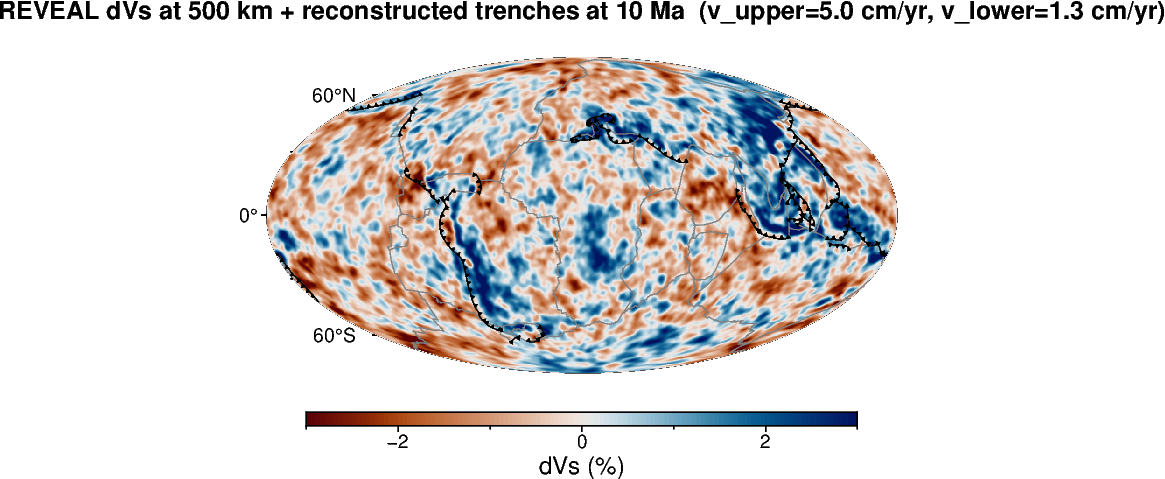

In [7]:
# Cell 6 — Panel slider
frame_bytes = {}
for depth_km in AVAILABLE_DEPTHS:
    p = CACHE / f"reveal_{depth_km:04d}km.png"
    if p.exists():
        frame_bytes[depth_km] = p.read_bytes()
print(f"Preloaded {len(frame_bytes)} frames into memory")

# DiscreteSlider snaps to the three available depths, with labels that
# include the sinking-rate-derived reconstruction age so the learner sees
# the depth → age conversion in the slider itself.
options = {
    f"{d} km  →  {depth_to_age(d):.0f} Ma": d for d in AVAILABLE_DEPTHS
}
slider = pn.widgets.DiscreteSlider(
    name="Depth (sinking-rate-derived age shown)",
    options=options, value=AVAILABLE_DEPTHS[0])
image_pane = pn.pane.PNG(object=frame_bytes[AVAILABLE_DEPTHS[0]], width=900)

def _update_image(event):
    if event.new in frame_bytes:
        image_pane.object = frame_bytes[event.new]
slider.param.watch(_update_image, "value")

pn.Column(image_pane, slider)

## Extend this

- **Sweep the sinking rate.** Call `render_reveal_map(depth_km, v_upper=..., v_lower=...)` with the published range bounds (Domeier 2016: 1.5–6 cm/yr upper, 1.1–1.9 cm/yr lower; van der Meer 2010 / Butterworth 2014: 1.2–1.3 cm/yr lower). The reconstructed-trench overlay will shift in time accordingly — slabs that move on/off the blue patches bound the plausible sinking-rate range for each region.
- **Different plate model.** Swap `Zahirovic2022` for `Cao2024` to see the trench positions through Precambrian times when REVEAL (https://reveal.sciencesconf.org/) still resolves slab structure. The lower-mantle slices (1500–2500 km) reach back beyond Zahirovic's 410 Ma horizon, so a deep-time model is needed there.
- **Extract more depth slices.** The bundled `data/reveal_tomography/` ships three depths (650, 1500, 2500 km) for size reasons. Run the bundled extraction code against the upstream `Models/REVEAL.nc` file to add depth slices of your own choosing (e.g., 410 km transition zone, 1000 km mid-upper-lower transition, 2890 km core-mantle boundary). Drop the new netCDFs into `data/reveal_tomography/` and the slider will pick them up automatically.
- **Quantify the agreement.** Compute a per-trench-segment distance between the reconstructed teeth and the nearest +1 % isocontour in the tomographic slice. Aggregate over time to obtain a region-by-region goodness-of-fit metric for the depth-to-age model.

## References

- Butterworth, N. P., Talsma, A. S., Müller, R. D., Seton, M., Bunge, H.-P., Schuberth, B. S. A., Shephard, G. E., & Heine, C. (2014). Geological, tomographic, kinematic and geodynamic constraints on the dynamics of sinking slabs. *Journal of Geodynamics*, 73, 1–13. https://doi.org/10.1016/j.jog.2013.10.006

- Domeier, M., Doubrovine, P. V., Torsvik, T. H., Spakman, W., & Bull, A. L. (2016). Global correlation of lower mantle structure and past subduction. *Geophysical Research Letters*, 43, 4945–4953. https://doi.org/10.1002/2016GL068827
- Flament, N., Williams, S., Müller, R. D., Gurnis, M., & Bower, D. J. (2017). Origin and evolution of the deep thermochemical structure beneath Eurasia. *Nature Communications*, 8, 14164. https://doi.org/10.1038/ncomms14164
- Mather, B. R., Müller, R. D., Zahirovic, S., Cannon, J., Chin, M., Ilano, L., Wright, N. M., Alfonso, C., Williams, S., Tetley, M., & Merdith, A. (2024). Deep time spatio-temporal data analysis using GPlately. *Geoscience Data Journal*, 11, 3–10. https://doi.org/10.1002/gdj3.185
- Thrastarson, S., van Herwaarden, D.-P., Noe, S., Schiller, C.J. & Fichtner, A. (2024). REVEAL: A global full-waveform inversion model. *Bulletin of the Seismological Society of America* 114, 1392–1406. https://doi.org/10.1785/0120230273
- Tian, D., Uieda, L., Leong, W. J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J., & Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.13679420
- van der Meer, D. G., Spakman, W., van Hinsbergen, D. J. J., Amaru, M. L., & Torsvik, T. H. (2010). Towards absolute plate motions constrained by lower-mantle slab remnants. *Nature Geoscience*, 3, 36–40. https://doi.org/10.1038/ngeo708
- Wessel, P., Luis, J. F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W. H. F., & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems*, 20, 5556–5564. https://doi.org/10.1029/2019GC008515
- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M. G., Young, A., & Müller, R. D. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal*, 9, 371–383. https://doi.org/10.1002/gdj3.146